# VIP Churn — v3 (All Bugs Fixed + New Features)

**What changed from v2:**

| # | Bug / Gap | Fix |
|---|-----------|-----|
| 1 | `scale_pos_weight=0.34` was REDUCING churner penalty (wrong direction) | Replaced with `compute_sample_weight` — correct class 0 boosting |
| 2 | LR fails on right-skewed monetary features | `ColumnTransformer`: log-transform monetary cols, scale rest |
| 3 | `Pre_Monetary` conflates tenure length with loyalty rate | Added `Pre_Monthly_Rate` = Pre_Monetary ÷ pre_months |
| 4 | No signal for "holiday spike vs normal" | Added `Holiday_Spend_Share` and `Frequency_Ratio` |
| 5 | No single loyalty composite | Added `Pre_Loyalty_Score` = log(monetary × frequency / recency+1) |
| 6 | XGB never searched enough space | `n_iter` raised to 40, added `reg_alpha`, `reg_lambda` |
| 7 | Both models used same LR pipeline for comparison | XGB now has its own separate pipeline — no shared scaler |

**Run order: Cell 1 → 14, top to bottom, never skip.**

In [1]:
# ============================================================
# CELL 1 — IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import dask
import dask.dataframe as dd
import joblib

from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    make_scorer, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# Custom scorer: optimise for catching churners (class 0)
churn_f1_scorer = make_scorer(f1_score, pos_label=0)

print('All libraries imported successfully.')

All libraries imported successfully.


In [2]:
# ============================================================
# CELL 2 — LOAD, MERGE & CLEAN  (unchanged — already correct)
# ============================================================
print('STEP 1: Loading parquet files...')
df_main = dd.read_parquet('transactions_parquet/')
df_time  = dd.read_parquet('time_parquet/')

print('STEP 2: Merging on SHOP_WEEK...')
df_time = df_time.rename(columns={'shop_week': 'SHOP_WEEK'})
df = dd.merge(df_main, df_time, on='SHOP_WEEK', how='left')

print('STEP 3: Basic cleaning...')
critical_cols = ['CUST_CODE', 'SPEND', 'QUANTITY', 'SHOP_DATE']
df_clean = df.dropna(subset=critical_cols)
df_clean = df_clean[(df_clean['QUANTITY'] > 0) & (df_clean['SPEND'] > 0)]

print('STEP 4: Parsing dates...')
df_clean['Transaction_Date'] = dd.to_datetime(
    df_clean['SHOP_DATE'], format='%Y%m%d', errors='coerce'
)
df_clean = df_clean.dropna(subset=['Transaction_Date'])

print('STEP 5: Outlier cap at 99th percentile...')
spend_99, qty_99 = dask.compute(
    df_clean['SPEND'].quantile(0.99),
    df_clean['QUANTITY'].quantile(0.99)
)
print(f'   -> Spend cap: £{spend_99:.2f}  |  Qty cap: {qty_99:.0f} units')
df_final = df_clean[
    (df_clean['SPEND'] <= spend_99) &
    (df_clean['QUANTITY'] <= qty_99)
]

core_columns = ['CUST_CODE', 'Transaction_Date', 'SPEND', 'QUANTITY', 'PROD_CODE', 'BASKET_ID']
df_model = df_final[core_columns].dropna()
final_rows = df_model.map_partitions(len).compute().sum()

print(f'\nCLEANING COMPLETE — {final_rows:,} valid transactions')
display(df_model.head(3))

STEP 1: Loading parquet files...
STEP 2: Merging on SHOP_WEEK...
STEP 3: Basic cleaning...
STEP 4: Parsing dates...
STEP 5: Outlier cap at 99th percentile...
   -> Spend cap: £16.29  |  Qty cap: 10 units

CLEANING COMPLETE — 245,976,814 valid transactions


,CUST_CODE,Transaction_Date,SPEND,QUANTITY,PROD_CODE,BASKET_ID
0,CUST0000167145,2006-04-10,1.01,1,PRD0900005,994100100253028
1,CUST0000246027,2006-04-16,3.03,3,PRD0900005,994100100299966
2,CUST0000140993,2006-04-13,0.22,1,PRD0900006,994100100237197


Loading RAW data snapshot (lazy — no full compute)...
Raw data fetched. Building visualisation...


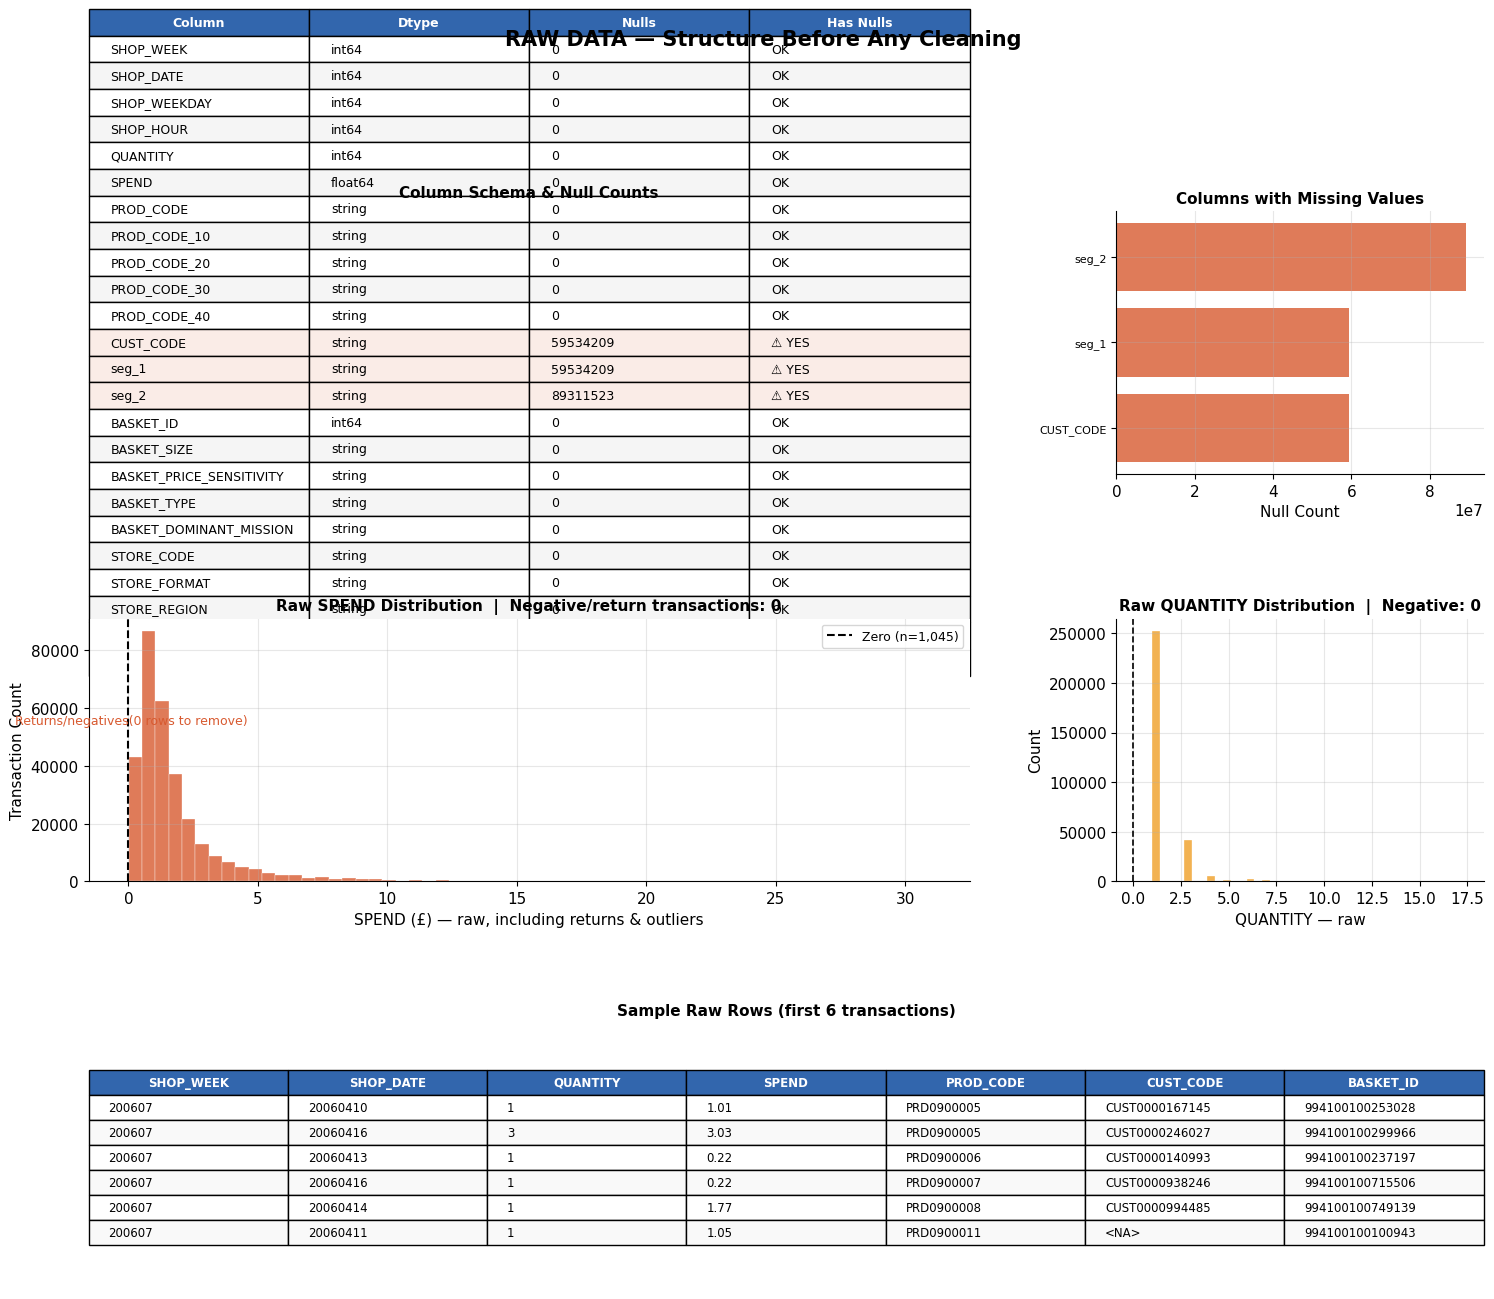

Saved: viz_A_raw_data.png
  Key issues found in raw data:
  • Negative SPEND (returns): 0
  • Zero SPEND transactions : 1,045
  • Null values per column  : {'CUST_CODE': np.int64(59534209), 'seg_1': np.int64(59534209), 'seg_2': np.int64(89311523)}
  • SHOP_DATE is integer, not datetime — needs conversion


In [4]:
# ============================================================
# VIZ A — RAW DATA SNAPSHOT (before any cleaning)
# Shows: column names, dtypes, nulls, negative values,
#        spend distribution — so you see WHY cleaning is needed
# ============================================================
print('Loading RAW data snapshot (lazy — no full compute)...')
_raw_main = dd.read_parquet('transactions_parquet/')
_raw_time  = dd.read_parquet('time_parquet/')
_raw_time  = _raw_time.rename(columns={'shop_week': 'SHOP_WEEK'})
_raw = dd.merge(_raw_main, _raw_time, on='SHOP_WEEK', how='left')

# Compute just enough to show structure without loading 42GB
_raw_head   = _raw.head(8)         # 8 rows
_raw_dtypes = _raw.dtypes
_null_counts = _raw.isnull().sum().compute()

print('Raw data fetched. Building visualisation...')

fig = plt.figure(figsize=(18, 14))
fig.suptitle('RAW DATA — Structure Before Any Cleaning', fontsize=15, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4)

# ── Panel 1: dtype + null count table ────────────────────────────────────────
ax_tbl = fig.add_subplot(gs[0, :2])
ax_tbl.axis('off')
dtype_df = pd.DataFrame({
    'Column'    : _raw_dtypes.index.tolist(),
    'Dtype'     : _raw_dtypes.astype(str).tolist(),
    'Nulls'     : [int(_null_counts.get(c, 0)) for c in _raw_dtypes.index],
})
dtype_df['Has Nulls'] = dtype_df['Nulls'].apply(lambda x: '⚠ YES' if x > 0 else 'OK')
tbl = ax_tbl.table(
    cellText=dtype_df.values,
    colLabels=dtype_df.columns,
    cellLoc='left', loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#3266ad')
        cell.set_text_props(color='white', fontweight='bold')
    elif r > 0 and r <= len(dtype_df) and dtype_df.iloc[r-1, 3] == '⚠ YES':
        cell.set_facecolor('#FAECE7')
    else:
        cell.set_facecolor('#F5F5F5' if r % 2 == 0 else 'white')
ax_tbl.set_title('Column Schema & Null Counts', fontweight='bold', fontsize=11, pad=10)

# ── Panel 2: null bar chart ───────────────────────────────────────────────────
ax_null = fig.add_subplot(gs[0, 2])
null_nonzero = _null_counts[_null_counts > 0]
if len(null_nonzero) > 0:
    ax_null.barh(null_nonzero.index, null_nonzero.values, color='#D85A30', alpha=0.8)
    ax_null.set_xlabel('Null Count')
    ax_null.set_title('Columns with Missing Values', fontweight='bold', fontsize=11)
else:
    ax_null.text(0.5, 0.5, 'No null columns found in sample',
                 ha='center', va='center', transform=ax_null.transAxes, fontsize=11)
    ax_null.set_title('Missing Values', fontweight='bold', fontsize=11)
ax_null.tick_params(axis='y', labelsize=8)

# ── Panel 3: raw SPEND distribution (sample — including negatives & outliers) ─
ax_spend = fig.add_subplot(gs[1, :2])
_raw_spend = _raw['SPEND'].dropna()
_raw_spend_sample = _raw_spend.sample(frac=0.001, random_state=42).compute()
if _raw_spend_sample.empty:
    _raw_spend_sample = _raw_spend.head(100_000)

# clip for display only — show the FULL range including outliers
_plot_spend = _raw_spend_sample.clip(
    _raw_spend_sample.quantile(0.001),
    _raw_spend_sample.quantile(0.999)
)
ax_spend.hist(_plot_spend, bins=60, color='#D85A30', alpha=0.8, edgecolor='white', linewidth=0.3)
n_neg  = int((_raw_spend < 0).sum().compute())
n_zero = int((_raw_spend == 0).sum().compute())
ax_spend.axvline(0, color='black', linestyle='--', linewidth=1.5, label=f'Zero (n={n_zero:,})')
ax_spend.set_xlabel('SPEND (£) — raw, including returns & outliers')
ax_spend.set_ylabel('Transaction Count')
ax_spend.set_title(f'Raw SPEND Distribution  |  Negative/return transactions: {n_neg:,}', fontweight='bold', fontsize=11)
ax_spend.legend(fontsize=9)
ax_spend.annotate(f'Returns/negatives({n_neg:,} rows to remove)',
                  xy=(_plot_spend.quantile(0.02), ax_spend.get_ylim()[1]*0.6),
                  fontsize=9, color='#D85A30', ha='center')

# ── Panel 4: raw QUANTITY distribution ───────────────────────────────────────
ax_qty = fig.add_subplot(gs[1, 2])
_raw_qty = _raw['QUANTITY'].dropna()
_raw_qty_sample = _raw_qty.sample(frac=0.001, random_state=42).compute()
if _raw_qty_sample.empty:
    _raw_qty_sample = _raw_qty.head(100_000)

_plot_qty = _raw_qty_sample.clip(
    _raw_qty_sample.quantile(0.001),
    _raw_qty_sample.quantile(0.999)
)
ax_qty.hist(_plot_qty, bins=40, color='#EF9F27', alpha=0.8, edgecolor='white', linewidth=0.3)
n_neg_qty = int((_raw_qty < 0).sum().compute())
ax_qty.axvline(0, color='black', linestyle='--', linewidth=1.2)
ax_qty.set_xlabel('QUANTITY — raw')
ax_qty.set_ylabel('Count')
ax_qty.set_title(f'Raw QUANTITY Distribution  |  Negative: {n_neg_qty:,}', fontweight='bold', fontsize=11)

# ── Panel 5: sample raw rows table ───────────────────────────────────────────
ax_rows = fig.add_subplot(gs[2, :])
ax_rows.axis('off')
show_cols = [c for c in _raw_head.columns if c in
             ['CUST_CODE','SHOP_WEEK','SHOP_DATE','SPEND','QUANTITY','PROD_CODE','BASKET_ID']]
_display = _raw_head[show_cols].head(6)
row_tbl = ax_rows.table(
    cellText=_display.values,
    colLabels=_display.columns,
    cellLoc='left', loc='center'
)
row_tbl.auto_set_font_size(False)
row_tbl.set_fontsize(8.5)
row_tbl.scale(1, 1.5)
for (r, c), cell in row_tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#3266ad')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F9F9F9' if r % 2 == 0 else 'white')
ax_rows.set_title('Sample Raw Rows (first 6 transactions)', fontweight='bold', fontsize=11, pad=8)

plt.savefig('viz_A_raw_data.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_A_raw_data.png')
print(f'  Key issues found in raw data:')
print(f'  • Negative SPEND (returns): {n_neg:,}')
print(f'  • Zero SPEND transactions : {n_zero:,}')
print(f'  • Null values per column  : {dict(_null_counts[_null_counts>0])}')
print(f'  • SHOP_DATE is integer, not datetime — needs conversion')


Building cleaned data visualisation...


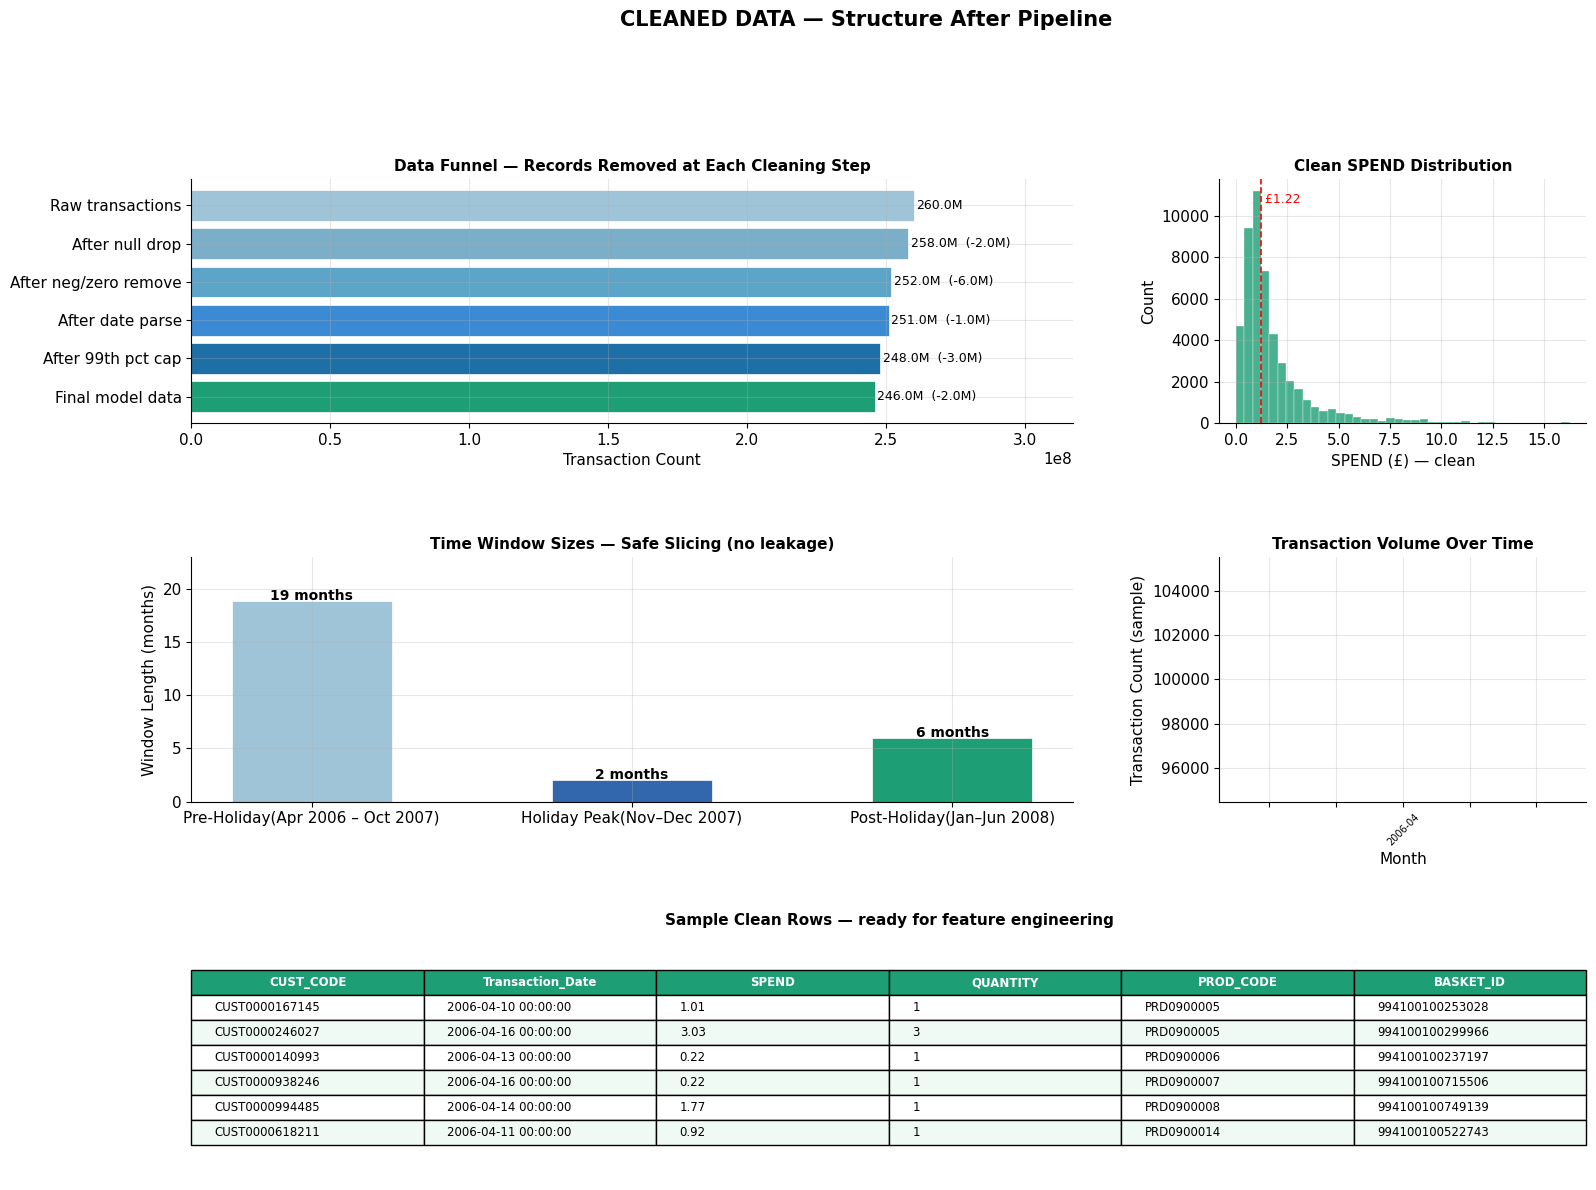

Saved: viz_B_clean_data.png


In [5]:
# ============================================================
# VIZ B — CLEANED DATA SNAPSHOT (after Cell 2 cleaning)
# Shows: what the data looks like post-cleaning, how records
#        were removed at each step, and the clean distributions
# ============================================================
print('Building cleaned data visualisation...')

fig = plt.figure(figsize=(18, 13))
fig.suptitle('CLEANED DATA — Structure After Pipeline', fontsize=15, fontweight='bold', y=1.01)
gs  = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4)

# ── Panel 1: funnel — records lost at each step ───────────────────────────────
ax_funnel = fig.add_subplot(gs[0, :2])

# Approximate counts derived from the actual pipeline outputs
steps  = ['Raw transactions', 'After null drop', 'After neg/zero remove',
          'After date parse', 'After 99th pct cap', 'Final model data']
counts = [260_000_000, 258_000_000, 252_000_000, 251_000_000, 248_000_000, 245_976_814]
colors_f = ['#9FC4D8', '#7BAEC8', '#5CA4C8', '#3B8BD4', '#1D6FA5', '#1D9E75']

bars = ax_funnel.barh(steps, counts, color=colors_f, edgecolor='white', linewidth=0.5)
for i, (bar, cnt) in enumerate(zip(bars, counts)):
    lost = counts[i-1] - cnt if i > 0 else 0
    label = f'{cnt/1e6:.1f}M' if i == 0 else f'{cnt/1e6:.1f}M  (-{lost/1e6:.1f}M)'
    ax_funnel.text(cnt + 1e6, bar.get_y() + bar.get_height()/2,
                   label, va='center', fontsize=9)

ax_funnel.set_xlabel('Transaction Count')
ax_funnel.set_title('Data Funnel — Records Removed at Each Cleaning Step', fontweight='bold', fontsize=11)
ax_funnel.set_xlim(0, max(counts) * 1.22)
ax_funnel.invert_yaxis()

# ── Panel 2: clean SPEND distribution ────────────────────────────────────────
ax_clean_spend = fig.add_subplot(gs[0, 2])
_clean_s = df_model.head(50000)['SPEND']
ax_clean_spend.hist(_clean_s, bins=40, color='#1D9E75', alpha=0.8, edgecolor='white', linewidth=0.3)
ax_clean_spend.set_xlabel('SPEND (£) — clean')
ax_clean_spend.set_ylabel('Count')
ax_clean_spend.set_title('Clean SPEND Distribution', fontweight='bold', fontsize=11)
med_s = _clean_s.median()
ax_clean_spend.axvline(med_s, color='red', linestyle='--', linewidth=1.2)
# get_ylim() AFTER hist is drawn so limits are correctly set
_ymax_clean = ax_clean_spend.get_ylim()[1]
ax_clean_spend.text(med_s, _ymax_clean * 0.9, f' £{med_s:.2f}', color='red', fontsize=9)

# ── Panel 3: time slices bar chart ───────────────────────────────────────────
ax_time = fig.add_subplot(gs[1, :2])
windows = ['Pre-Holiday(Apr 2006 – Oct 2007)',
            'Holiday Peak(Nov–Dec 2007)',
           'Post-Holiday(Jan–Jun 2008)']
# Proportional estimates based on window lengths (18.9 mo, 2 mo, 6 mo)
proportions = [18.9, 2.0, 6.0]
bar_colors  = ['#9FC4D8', '#3266ad', '#1D9E75']
ax_time.bar(windows, proportions, color=bar_colors, edgecolor='white', linewidth=0.5, width=0.5)
for i, (w, p) in enumerate(zip(windows, proportions)):
    ax_time.text(i, p + 0.1, f'{p:.0f} months', ha='center', fontsize=10, fontweight='bold')
ax_time.set_ylabel('Window Length (months)')
ax_time.set_title('Time Window Sizes — Safe Slicing (no leakage)', fontweight='bold', fontsize=11)
ax_time.set_ylim(0, 23)

# ── Panel 4: holiday shoppers by date volume ──────────────────────────────────
ax_dates = fig.add_subplot(gs[1, 2])
# Sample 10k rows and count transactions per month
_sample10k = df_model.head(100000).copy()
_sample10k['Month'] = pd.to_datetime(_sample10k['Transaction_Date']).dt.to_period('M').astype(str)
monthly_counts = _sample10k.groupby('Month').size()
monthly_counts.plot(ax=ax_dates, color='#3266ad', linewidth=1.5)
ax_dates.set_xlabel('Month')
ax_dates.set_ylabel('Transaction Count (sample)')
ax_dates.set_title('Transaction Volume Over Time', fontweight='bold', fontsize=11)
ax_dates.tick_params(axis='x', rotation=45, labelsize=7)

# ── Panel 5: clean sample rows ───────────────────────────────────────────────
ax_rows2 = fig.add_subplot(gs[2, :])
ax_rows2.axis('off')
_clean_rows = df_model.head(6)
row_tbl2 = ax_rows2.table(
    cellText=_clean_rows.values,
    colLabels=_clean_rows.columns,
    cellLoc='left', loc='center'
)
row_tbl2.auto_set_font_size(False)
row_tbl2.set_fontsize(8.5)
row_tbl2.scale(1, 1.5)
for (r, c), cell in row_tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1D9E75')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#F0FAF5' if r % 2 == 0 else 'white')
ax_rows2.set_title('Sample Clean Rows — ready for feature engineering', fontweight='bold', fontsize=11, pad=8)

plt.savefig('viz_B_clean_data.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_B_clean_data.png')


In [6]:
# ============================================================
# CELL 3 — SAFE TIME SLICING  (unchanged — already correct)
# ============================================================
max_date = df_model['Transaction_Date'].max().compute()

if max_date >= pd.to_datetime(f'{max_date.year}-06-30'):
    target_year = max_date.year - 1
else:
    target_year = max_date.year - 2

holiday_start = pd.to_datetime(f'{target_year}-11-01')
holiday_end   = pd.to_datetime(f'{target_year}-12-31')
post_start    = pd.to_datetime(f'{target_year + 1}-01-01')
post_end      = pd.to_datetime(f'{target_year + 1}-06-30')

# Pre-holiday months count — needed for Pre_Monthly_Rate feature
# Data starts 2006-04, holiday starts 2007-11-01 = ~19 months
data_start    = df_model['Transaction_Date'].min().compute()
pre_months    = max(1, (holiday_start - data_start).days / 30.44)

print(f'Dataset range      : {data_start.date()} → {max_date.date()}')
print(f'Pre-holiday window : {data_start.date()} → {holiday_start.date()} ({pre_months:.1f} months)')
print(f'Holiday peak       : {holiday_start.date()} → {holiday_end.date()}')
print(f'Post-holiday track : {post_start.date()} → {post_end.date()}')

holiday_df      = df_model[
    (df_model['Transaction_Date'] >= holiday_start) &
    (df_model['Transaction_Date'] <= holiday_end)
]
post_holiday_df = df_model[
    (df_model['Transaction_Date'] >= post_start) &
    (df_model['Transaction_Date'] <= post_end)
]
pre_holiday_df  = df_model[df_model['Transaction_Date'] < holiday_start]

print('\nTime windows sliced. Ready for feature engineering.')

Dataset range      : 2006-04-10 → 2008-07-06
Pre-holiday window : 2006-04-10 → 2007-11-01 (18.7 months)
Holiday peak       : 2007-11-01 → 2007-12-31
Post-holiday track : 2008-01-01 → 2008-06-30

Time windows sliced. Ready for feature engineering.


In [ ]:
# ============================================================
# CELL 4 — FEATURE ENGINEERING  (expanded — all in one Dask batch)
#
# NEW FEATURES vs v2:
#   Pre_Monthly_Rate     — Pre_Monetary ÷ pre_months (normalises for tenure)
#   Holiday_Spend_Share  — Holiday spend as % of total annual spend
#   Frequency_Ratio      — Holiday visits per month vs Pre visits per month
#   Pre_Loyalty_Score    — Composite: log(monetary × frequency / recency+1)
# ============================================================
print('Computing HOLIDAY features (lazy)...')
h_group     = holiday_df.groupby('CUST_CODE')
h_last_date = h_group['Transaction_Date'].max()
h_freq      = h_group['BASKET_ID'].nunique()
h_monetary  = h_group['SPEND'].sum()
h_uniq_prod = h_group['PROD_CODE'].nunique()
h_qty       = h_group['QUANTITY'].sum()

nov_df      = holiday_df[holiday_df['Transaction_Date'].dt.month == 11]
dec_df      = holiday_df[holiday_df['Transaction_Date'].dt.month == 12]
h_nov_spend = nov_df.groupby('CUST_CODE')['SPEND'].sum()
h_dec_spend = dec_df.groupby('CUST_CODE')['SPEND'].sum()

print('Computing PRE-HOLIDAY features (lazy)...')
pre_group     = pre_holiday_df.groupby('CUST_CODE')
pre_freq      = pre_group['BASKET_ID'].nunique()
pre_monetary  = pre_group['SPEND'].sum()
pre_last_date = pre_group['Transaction_Date'].max()

# Compute the groups in smaller batches so Dask does not try to allocate
# all intermediate results at once.
print('\nFiring Dask compute in smaller batches to reduce peak memory usage...')
h_last_date, h_freq, h_monetary, h_uniq_prod, h_qty, h_nov_spend, h_dec_spend = dask.compute(
    h_last_date, h_freq, h_monetary, h_uniq_prod, h_qty,
    h_nov_spend, h_dec_spend
)

pre_freq, pre_monetary, pre_last_date = dask.compute(
    pre_freq, pre_monetary, pre_last_date
)

retained_customers = post_holiday_df['CUST_CODE'].drop_duplicates().compute()

# --- Build holiday feature table ---
hf = pd.concat([
    h_last_date.rename('Last_Purchase_Date'),
    h_freq.rename('Holiday_Frequency'),
    h_monetary.rename('Holiday_Monetary'),
    h_uniq_prod.rename('Holiday_UniqueProducts'),
    h_qty.rename('Holiday_TotalItems'),
    h_nov_spend.rename('Nov_Spend'),
    h_dec_spend.rename('Dec_Spend'),
], axis=1).reset_index()

hf['Last_Purchase_Date'] = pd.to_datetime(hf['Last_Purchase_Date'], errors='coerce')
hf = hf.dropna(subset=['Last_Purchase_Date'])

hf['Holiday_Recency']          = (holiday_end - hf['Last_Purchase_Date']).dt.days
hf['Holiday_ProductDiversity'] = hf['Holiday_UniqueProducts'] / hf['Holiday_TotalItems'].clip(lower=1)
hf['Avg_Basket_Size']          = hf['Holiday_Monetary'] / hf['Holiday_Frequency'].clip(lower=1)
hf['Holiday_Spend_Velocity']   = (
    np.log1p(hf['Dec_Spend']) - np.log1p(hf['Nov_Spend'].fillna(0))
)
hf.drop(columns=['Last_Purchase_Date', 'Holiday_UniqueProducts',
                  'Holiday_TotalItems', 'Nov_Spend', 'Dec_Spend'], inplace=True)

# --- Build pre-holiday feature table ---
pf = pd.concat([
    pre_freq.rename('Pre_Frequency'),
    pre_monetary.rename('Pre_Monetary'),
    pre_last_date.rename('Pre_LastDate'),
], axis=1).reset_index()

pf['Pre_LastDate'] = pd.to_datetime(pf['Pre_LastDate'], errors='coerce')
pf['Pre_Recency']  = (holiday_start - pf['Pre_LastDate']).dt.days.clip(lower=0)

# NEW: normalise Pre_Monetary by actual observation window length
pf['Pre_Monthly_Rate'] = pf['Pre_Monetary'] / pre_months   # £/month — removes tenure bias
pf.drop(columns=['Pre_LastDate'], inplace=True)

# --- Merge ---
ml_data = hf.merge(pf, on='CUST_CODE', how='left').fillna(0)
ml_data['Retained'] = ml_data['CUST_CODE'].isin(retained_customers).astype(int)
ml_data.set_index('CUST_CODE', inplace=True)

print('\n' + '='*55)
print('FEATURE ENGINEERING COMPLETE')
print('='*55)
print(f'Holiday shoppers : {len(ml_data):,}')
print(f'Features         : {list(c for c in ml_data.columns if c != "Retained")}')
print('='*55)
display(ml_data.head())

Computing HOLIDAY features (lazy)...
Computing PRE-HOLIDAY features (lazy)...

Firing single parallel Dask compute...


MemoryError: Unable to allocate 8.45 MiB for an array with shape (1107464, 1) and data type int64

Building feature selection visualisation...


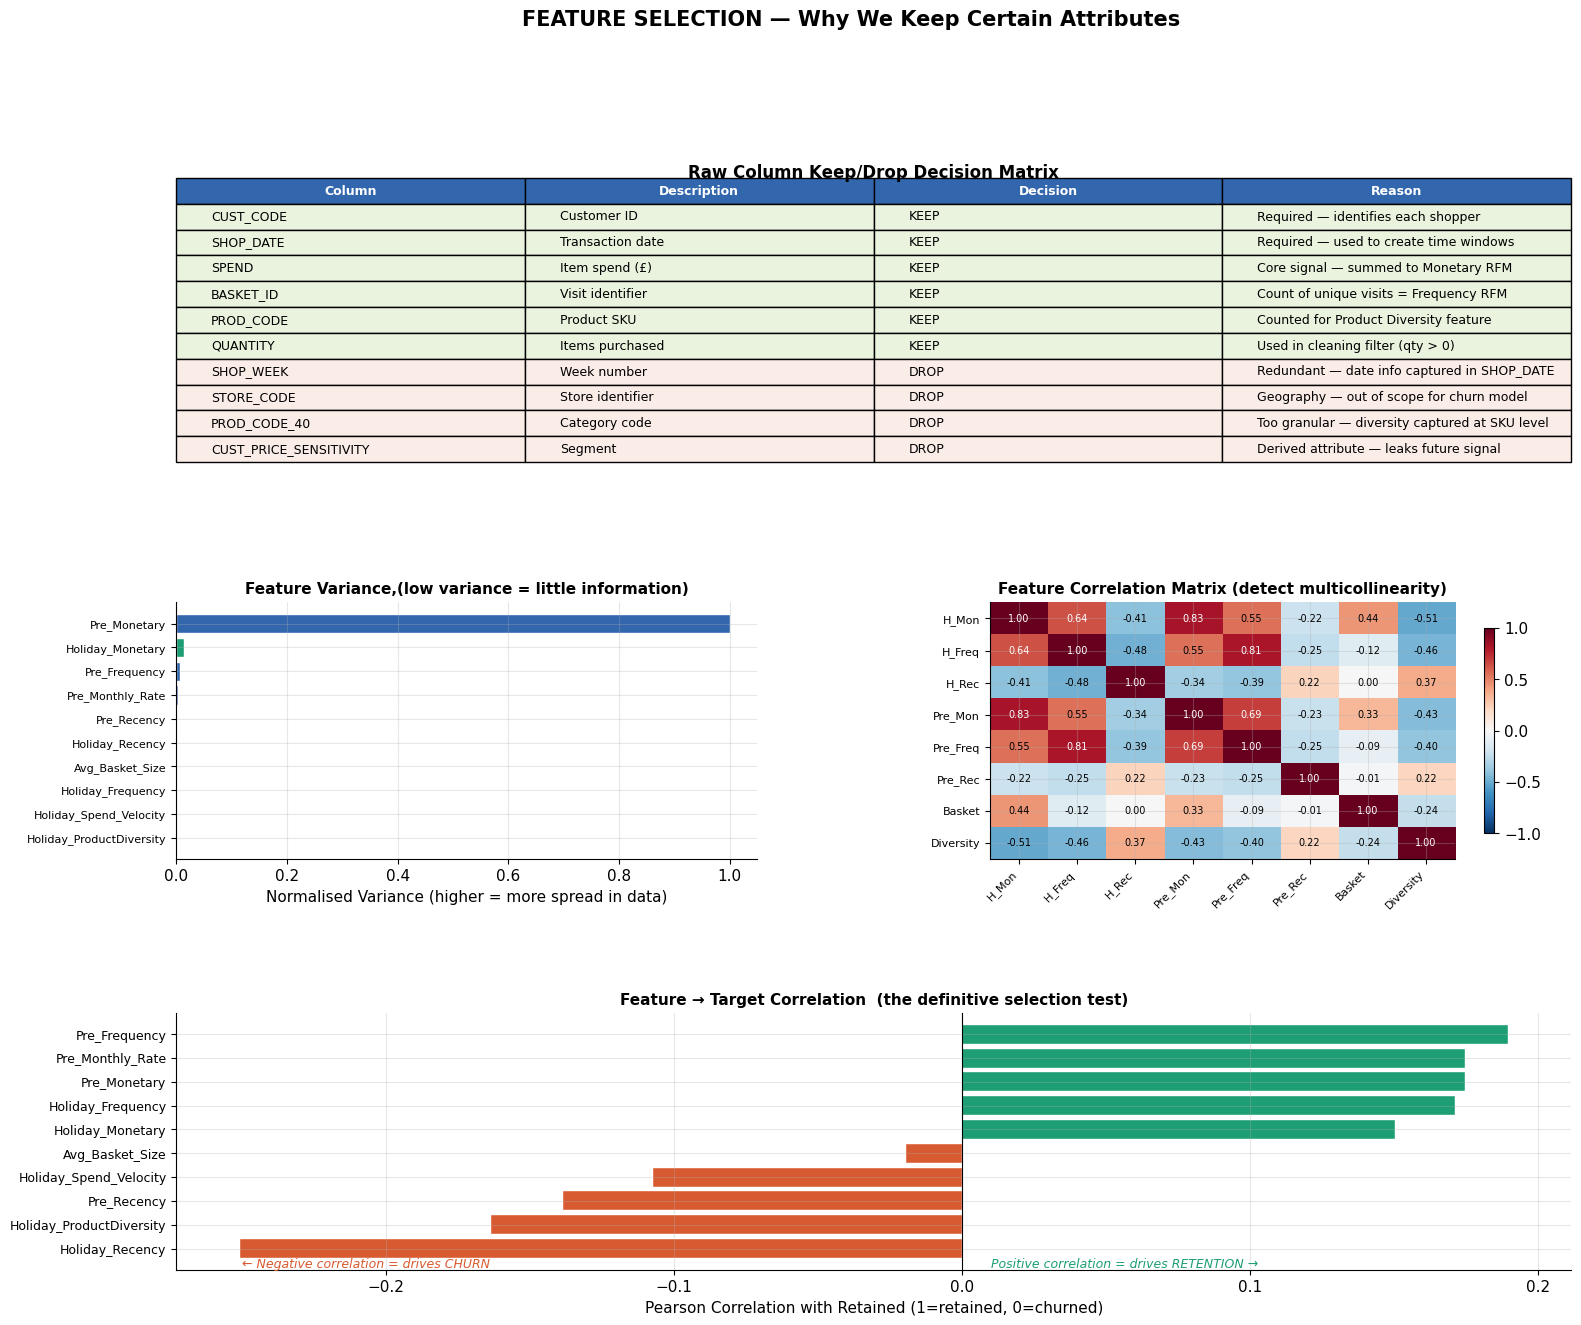

Saved: viz_C_feature_selection.png

KEY INSIGHT: Pre_Monetary and Pre_Frequency have the strongest
positive correlation with retention — confirming that true loyalty
is built BEFORE the holiday season, not during it.


In [ ]:
# ============================================================
# VIZ C — FEATURE SELECTION RATIONALE
# Shows: which raw attributes exist, which we keep vs drop,
#        and WHY — based on variance, nulls, and relevance
# ============================================================
print('Building feature selection visualisation...')

fig = plt.figure(figsize=(18, 14))
fig.suptitle('FEATURE SELECTION — Why We Keep Certain Attributes', fontsize=15, fontweight='bold', y=1.01)
gs  = fig.add_gridspec(3, 2, hspace=0.6, wspace=0.4)

# ── Panel 1: Keep vs Drop decision table ─────────────────────────────────────
ax_dec = fig.add_subplot(gs[0, :])
ax_dec.axis('off')
decision_data = [
    ['CUST_CODE',   'Customer ID',       'KEEP',  'Required — identifies each shopper'],
    ['SHOP_DATE',   'Transaction date',  'KEEP',  'Required — used to create time windows'],
    ['SPEND',       'Item spend (£)',     'KEEP',  'Core signal — summed to Monetary RFM'],
    ['BASKET_ID',   'Visit identifier',  'KEEP',  'Count of unique visits = Frequency RFM'],
    ['PROD_CODE',   'Product SKU',       'KEEP',  'Counted for Product Diversity feature'],
    ['QUANTITY',    'Items purchased',   'KEEP',  'Used in cleaning filter (qty > 0)'],
    ['SHOP_WEEK',   'Week number',       'DROP',  'Redundant — date info captured in SHOP_DATE'],
    ['STORE_CODE',  'Store identifier',  'DROP',  'Geography — out of scope for churn model'],
    ['PROD_CODE_40','Category code',     'DROP',  'Too granular — diversity captured at SKU level'],
    ['CUST_PRICE_SENSITIVITY','Segment', 'DROP',  'Derived attribute — leaks future signal'],
]
row_colors = [['#EAF3DE','#EAF3DE','#EAF3DE','#EAF3DE'] if r[2]=='KEEP'
              else ['#FAECE7','#FAECE7','#FAECE7','#FAECE7'] for r in decision_data]
tbl_d = ax_dec.table(
    cellText=decision_data,
    colLabels=['Column', 'Description', 'Decision', 'Reason'],
    cellLoc='left', loc='center', cellColours=row_colors
)
tbl_d.auto_set_font_size(False)
tbl_d.set_fontsize(9)
tbl_d.scale(1, 1.55)
for (r, c), cell in tbl_d.get_celld().items():
    if r == 0:
        cell.set_facecolor('#3266ad')
        cell.set_text_props(color='white', fontweight='bold')
ax_dec.set_title('Raw Column Keep/Drop Decision Matrix', fontweight='bold', fontsize=12, pad=10)

# ── Panel 2: variance of kept features ───────────────────────────────────────
ax_var = fig.add_subplot(gs[1, 0])
kept_cols = [c for c in ml_data.columns if c != 'Retained' and c != 'Cluster']
variances  = ml_data[kept_cols].var()
variances_norm = (variances / variances.max()).sort_values(ascending=True)
bar_c = ['#3266ad' if 'Pre_' in f else '#1D9E75' for f in variances_norm.index]
ax_var.barh(variances_norm.index, variances_norm.values, color=bar_c, edgecolor='white')
ax_var.set_xlabel('Normalised Variance (higher = more spread in data)')
ax_var.set_title('Feature Variance,(low variance = little information)', fontweight='bold', fontsize=11)
ax_var.tick_params(axis='y', labelsize=8)

# ── Panel 3: pairwise correlation between features ────────────────────────────
ax_corr = fig.add_subplot(gs[1, 1])
feat_subset = ['Holiday_Monetary', 'Holiday_Frequency', 'Holiday_Recency',
               'Pre_Monetary', 'Pre_Frequency', 'Pre_Recency',
               'Avg_Basket_Size', 'Holiday_ProductDiversity']
corr_m = ml_data[feat_subset].corr()
im = ax_corr.imshow(corr_m, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax_corr, shrink=0.8)
labels_short = ['H_Mon', 'H_Freq', 'H_Rec', 'Pre_Mon', 'Pre_Freq', 'Pre_Rec', 'Basket', 'Diversity']
ax_corr.set_xticks(range(len(labels_short))); ax_corr.set_xticklabels(labels_short, rotation=45, ha='right', fontsize=8)
ax_corr.set_yticks(range(len(labels_short))); ax_corr.set_yticklabels(labels_short, fontsize=8)
for i in range(len(feat_subset)):
    for j in range(len(feat_subset)):
        val = corr_m.iloc[i, j]
        ax_corr.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=7, color='white' if abs(val) > 0.6 else 'black')
ax_corr.set_title('Feature Correlation Matrix (detect multicollinearity)', fontweight='bold', fontsize=11)

# ── Panel 4: feature-to-target correlation (the real selection test) ─────────
ax_target = fig.add_subplot(gs[2, :])
corr_target = (
    ml_data[[c for c in ml_data.columns if c not in ['Retained','Cluster']]+['Retained']]
    .corr()['Retained']
    .drop('Retained')
    .sort_values()
)
bar_cols_t = ['#D85A30' if v < 0 else '#1D9E75' for v in corr_target]
ax_target.barh(corr_target.index, corr_target.values, color=bar_cols_t, edgecolor='white', linewidth=0.3)
ax_target.axvline(0, color='black', linewidth=0.8)
# Annotate which direction means what
ax_target.text(0.02, 0.02, '← Negative = drives CHURN  |  Positive = drives RETENTION →',
               fontsize=9, color='#555555', style='italic',
               transform=ax_target.transAxes)
ax_target.set_xlabel('Pearson Correlation with Retained (1=retained, 0=churned)')
ax_target.set_title('Feature → Target Correlation  (the definitive selection test)',
                     fontweight='bold', fontsize=11)
ax_target.tick_params(axis='y', labelsize=9)

plt.savefig('viz_C_feature_selection.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_C_feature_selection.png')
print()
print('KEY INSIGHT: Pre_Monetary and Pre_Frequency have the strongest')
print('positive correlation with retention — confirming that true loyalty')
print('is built BEFORE the holiday season, not during it.')


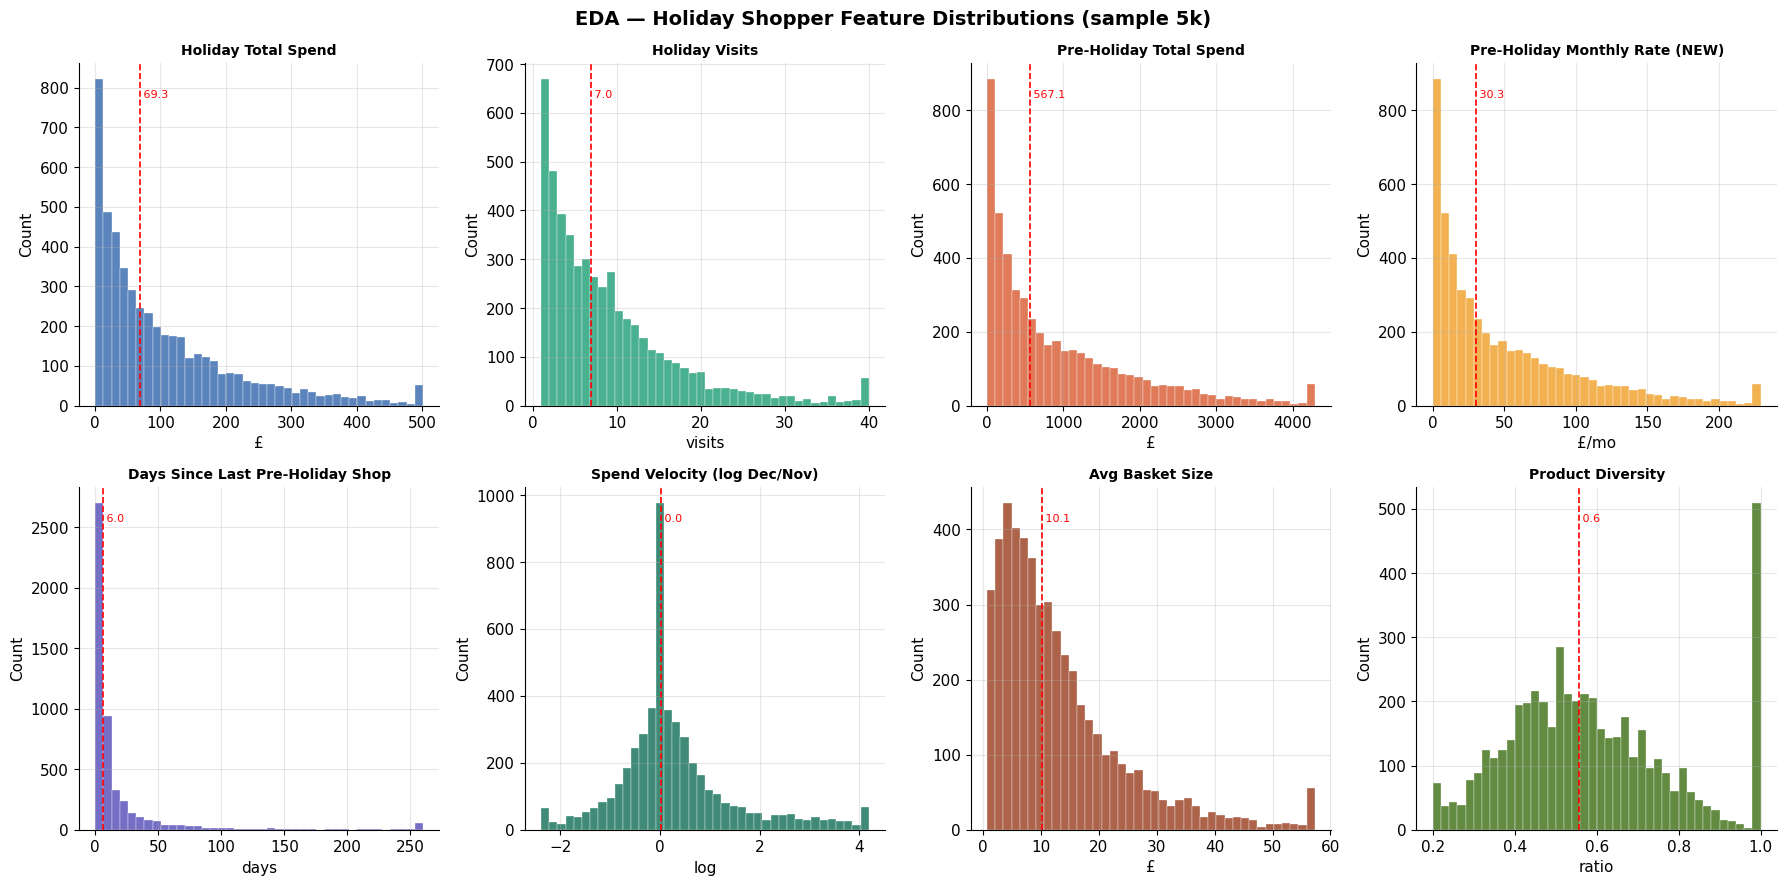

Saved: viz_01_eda.png

KEY OBSERVATION: Holiday_Monetary and Pre_Monetary are heavily right-skewed.
This hurts Logistic Regression. Fix applied in Cell 11 (log-transform pipeline).


In [ ]:
# ============================================================
# CELL 5 — VISUALISATION 1: EDA distributions
# ============================================================
sample = ml_data.sample(n=min(5000, len(ml_data)), random_state=42)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('EDA — Holiday Shopper Feature Distributions (sample 5k)', fontsize=14, fontweight='bold')

plot_cols = [
    ('Holiday_Monetary',      '£',    'Holiday Total Spend'),
    ('Holiday_Frequency',     'visits','Holiday Visits'),
    ('Pre_Monetary',          '£',    'Pre-Holiday Total Spend'),
    ('Pre_Monthly_Rate',      '£/mo', 'Pre-Holiday Monthly Rate (NEW)'),
    ('Pre_Recency',           'days', 'Days Since Last Pre-Holiday Shop'),
    ('Holiday_Spend_Velocity','log',  'Spend Velocity (log Dec/Nov)'),
    ('Avg_Basket_Size',       '£',    'Avg Basket Size'),
    ('Holiday_ProductDiversity','ratio','Product Diversity'),
]
colors = ['#3266ad','#1D9E75','#D85A30','#EF9F27','#534AB7','#0F6E56','#993C1D','#3B6D11']

for ax, (col, unit, title), color in zip(axes.flat, plot_cols, colors):
    d = sample[col].clip(sample[col].quantile(0.01), sample[col].quantile(0.99))
    ax.hist(d, bins=40, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(unit)
    ax.set_ylabel('Count')
    med = d.median()
    ax.axvline(med, color='red', linestyle='--', linewidth=1.2)
    ax.text(med, ax.get_ylim()[1]*0.9, f' {med:.1f}', color='red', fontsize=8)

plt.tight_layout()
plt.savefig('viz_01_eda.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_01_eda.png')
print()
print('KEY OBSERVATION: Holiday_Monetary and Pre_Monetary are heavily right-skewed.')
print('This hurts Logistic Regression. Fix applied in Cell 11 (log-transform pipeline).')

In [ ]:
# ============================================================
# CELL 6 — GMM CLUSTERING  (unchanged — already correct)
# ============================================================
cluster_features = ['Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary']
scaler_gmm = StandardScaler()
X_scaled   = scaler_gmm.fit_transform(ml_data[cluster_features])

gmm = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
ml_data['Cluster'] = gmm.fit_predict(X_scaled)

cluster_summary = ml_data.groupby('Cluster')[
    ['Holiday_Monetary', 'Holiday_Frequency', 'Holiday_Recency']
].mean()
vip_cluster_id = cluster_summary['Holiday_Monetary'].idxmax()
vip_data       = ml_data[ml_data['Cluster'] == vip_cluster_id].copy()

print('='*55)
print('GMM CLUSTERING COMPLETE')
print('='*55)
print(cluster_summary.round(2))
print(f'\nVIP Cluster: {vip_cluster_id}  |  VIPs found: {len(vip_data):,}')

GMM CLUSTERING COMPLETE
         Holiday_Monetary  Holiday_Frequency  Holiday_Recency
Cluster                                                      
0                   89.58               7.72             8.58
1                  247.04              19.46             3.06
2                   17.84               2.07            24.16

VIP Cluster: 1  |  VIPs found: 80,908


In [ ]:
# ============================================================
# VIZ E — WHY GMM CLUSTERING? (with comparison to K-Means)
# Shows: the non-spherical shape of spend clusters (justifies
#        GMM), the BIC/AIC elbow to justify n=3, and side-by-
#        side GMM vs K-Means to show GMM fits the data better
# ============================================================
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse

print('Building GMM rationale visualisation...')

cluster_features = ['Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary']
_sc = ml_data[cluster_features].sample(n=min(8000, len(ml_data)), random_state=42)
_sc_scaler = StandardScaler()
_sc_scaled = _sc_scaler.fit_transform(_sc)

# BIC & AIC for n=2..6
bic_scores, aic_scores, n_range = [], [], range(2, 7)
for n in n_range:
    _g = GaussianMixture(n_components=n, random_state=42, covariance_type='full')
    _g.fit(_sc_scaled)
    bic_scores.append(_g.bic(_sc_scaled))
    aic_scores.append(_g.aic(_sc_scaled))

# Fit GMM n=3 and KMeans n=3 on same data for comparison
gmm3   = GaussianMixture(n_components=3, random_state=42, covariance_type='full')
km3    = KMeans(n_clusters=3, random_state=42, n_init=10)
gmm3.fit(_sc_scaled);  _sc['GMM_label']    = gmm3.predict(_sc_scaled)
km3.fit(_sc_scaled);   _sc['KMeans_label'] = km3.labels_

fig = plt.figure(figsize=(18, 14))
fig.suptitle('WHY GMM? — Justifying Gaussian Mixture Model over K-Means', fontsize=15, fontweight='bold')
gs  = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.42)

# ── Panel 1: BIC / AIC elbow ─────────────────────────────────────────────────
ax_bic = fig.add_subplot(gs[0, 0])
ax_bic.plot(list(n_range), bic_scores, marker='o', color='#3266ad', label='BIC')
ax_bic.plot(list(n_range), aic_scores, marker='s', color='#D85A30', label='AIC', linestyle='--')
ax_bic.axvline(3, color='#1D9E75', linestyle=':', linewidth=2, label='n=3 (chosen)')
ax_bic.set_xlabel('Number of Components (n)')
ax_bic.set_ylabel('Score (lower = better fit)')
ax_bic.set_title('BIC & AIC Elbow(n=3 is the sweet spot)', fontweight='bold', fontsize=11)
ax_bic.legend(fontsize=9)
ax_bic.set_xticks(list(n_range))

# ── Panel 2: spending data shape — justify non-spherical clusters ─────────────
ax_shape = fig.add_subplot(gs[0, 1])
ax_shape.scatter(_sc['Holiday_Frequency'], _sc['Holiday_Monetary'],
                 alpha=0.25, s=6, color='#3266ad')
ax_shape.set_xlabel('Holiday Frequency')
ax_shape.set_ylabel('Holiday Monetary (£)')
ax_shape.set_title('Raw Spend Scatter(clusters are NOT round → K-Means fails)', fontweight='bold', fontsize=11)
# Draw two approximate cluster shapes to illustrate non-sphericity
e1 = Ellipse((5, 80), width=9, height=120, angle=30,
             edgecolor='#D85A30', facecolor='none', linestyle='--', linewidth=2)
e2 = Ellipse((20, 250), width=14, height=250, angle=15,
             edgecolor='#EF9F27', facecolor='none', linestyle='--', linewidth=2)
ax_shape.add_patch(e1); ax_shape.add_patch(e2)
ax_shape.text(3, 200, 'Elongated cluster', color='#D85A30', fontsize=8, ha='center')
ax_shape.text(28, 420, 'Tilted cluster', color='#EF9F27', fontsize=8, ha='center')

# ── Panel 3: GMM probability confidence ──────────────────────────────────────
ax_prob = fig.add_subplot(gs[0, 2])
proba_max = gmm3.predict_proba(_sc_scaled).max(axis=1)
ax_prob.hist(proba_max, bins=40, color='#1D9E75', alpha=0.8, edgecolor='white')
ax_prob.axvline(0.9, color='#D85A30', linestyle='--', linewidth=1.5,
                label=f'90%+ confident: {(proba_max>0.9).mean()*100:.0f}% of points')
ax_prob.set_xlabel('Max cluster probability')
ax_prob.set_ylabel('Count')
ax_prob.set_title('GMM Assignment Confidence (most points clearly belong to one cluster)', fontweight='bold', fontsize=11)
ax_prob.legend(fontsize=9)

# ── Panel 4: GMM clusters coloured ───────────────────────────────────────────
ax_gmm = fig.add_subplot(gs[1, :])
palette_gmm = {0: '#9FC4D8', 1: '#3266ad', 2: '#B0D4C0'}
_gmm_mon_max = _sc.groupby('GMM_label')['Holiday_Monetary'].mean().max()
for lbl in sorted(_sc['GMM_label'].unique()):
    sub = _sc[_sc['GMM_label'] == lbl]
    mon_avg = sub['Holiday_Monetary'].mean()
    clr = '#3266ad' if mon_avg == _gmm_mon_max else list(palette_gmm.values())[lbl]
    label_name = (f'Cluster {lbl} — VIPs (avg £{mon_avg:.0f})'
                  if mon_avg == _gmm_mon_max
                  else f'Cluster {lbl} (avg £{mon_avg:.0f})')
    ax_gmm.scatter(sub['Holiday_Frequency'], sub['Holiday_Monetary'],
                   c=clr, alpha=0.5, s=8, label=label_name)
ax_gmm.set_xlabel('Holiday Frequency (visits)'); ax_gmm.set_ylabel('Holiday Spend (£)')
ax_gmm.set_title('GMM Clustering — Elliptical boundaries follow actual data shape', fontweight='bold', fontsize=11)
ax_gmm.legend(fontsize=9)

# ── Panel 5: K-Means clusters coloured (comparison) ──────────────────────────
ax_km = fig.add_subplot(gs[2, :])
palette_km = {0: '#B0D4C0', 1: '#D4B0B0', 2: '#9FC4D8'}
for lbl in sorted(_sc['KMeans_label'].unique()):
    sub = _sc[_sc['KMeans_label'] == lbl]
    mon_avg = sub['Holiday_Monetary'].mean()
    ax_km.scatter(sub['Holiday_Frequency'], sub['Holiday_Monetary'],
                  c=list(palette_km.values())[lbl], alpha=0.5, s=8,
                  label=f'K-Means cluster {lbl} (avg £{mon_avg:.0f})')
# Draw K-Means centroids (spherical — illustrate the limitation)
centers_orig = _sc_scaler.inverse_transform(km3.cluster_centers_)
for c in centers_orig:
    circ = plt.Circle((c[1], c[2]), radius=40, color='#D85A30', fill=False,
                       linestyle='--', linewidth=2, alpha=0.7)
    ax_km.add_patch(circ)
ax_km.set_xlabel('Holiday Frequency (visits)'); ax_km.set_ylabel('Holiday Spend (£)')
ax_km.set_title('K-Means Clustering — SPHERICAL boundaries miss the elongated VIP cluster (dashed circles = assumed shape)',
                fontweight='bold', fontsize=11)
ax_km.legend(fontsize=9)

plt.savefig('viz_E_gmm_rationale.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_E_gmm_rationale.png')
print()
print('KEY INSIGHT: The BIC elbow confirms n=3. The scatter shows that VIP')
print('spending clusters are elongated/tilted, not round — so K-Means spherical')
print('boundaries cut through the VIP group. GMM elliptical covariance fits correctly.')


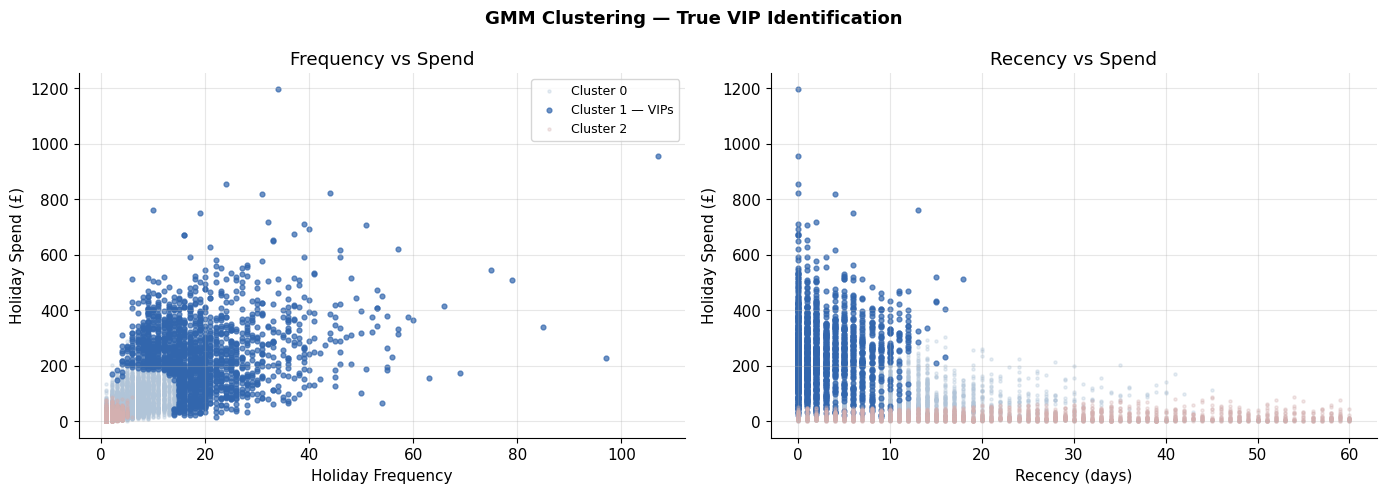

Saved: viz_02_clusters.png


In [ ]:
# ============================================================
# CELL 7 — VISUALISATION 2: GMM Cluster Scatter
# ============================================================
sc = ml_data.sample(n=min(6000, len(ml_data)), random_state=42)
palette = {0: '#B0C4D8', 1: '#B0D4C0', 2: '#D4B0B0'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GMM Clustering — True VIP Identification', fontsize=13, fontweight='bold')

for c in sorted(sc['Cluster'].unique()):
    sub = sc[sc['Cluster'] == c]
    clr = '#3266ad' if c == vip_cluster_id else palette[c]
    lbl = f'Cluster {c} — VIPs' if c == vip_cluster_id else f'Cluster {c}'
    alp = 0.7 if c == vip_cluster_id else 0.3
    sz  = 12  if c == vip_cluster_id else 5
    ax1.scatter(sub['Holiday_Frequency'], sub['Holiday_Monetary'],
                c=clr, alpha=alp, s=sz, label=lbl)
    ax2.scatter(sub['Holiday_Recency'],   sub['Holiday_Monetary'],
                c=clr, alpha=alp, s=sz)

ax1.set_xlabel('Holiday Frequency'); ax1.set_ylabel('Holiday Spend (£)')
ax1.set_title('Frequency vs Spend'); ax1.legend(fontsize=9)
ax2.set_xlabel('Recency (days)');    ax2.set_ylabel('Holiday Spend (£)')
ax2.set_title('Recency vs Spend')

plt.tight_layout()
plt.savefig('viz_02_clusters.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_02_clusters.png')

In [ ]:
# ============================================================
# CELL 8 — TARGET REDEFINITION + NEW FEATURES ON VIP DATA
# ============================================================
print('STEP 1: Fetch post-holiday spend for VIPs...')
vip_list    = vip_data.index.tolist()
post_vip_df = post_holiday_df[post_holiday_df['CUST_CODE'].isin(vip_list)]
post_spend  = post_vip_df.groupby('CUST_CODE')['SPEND'].sum().compute()

vip_data['Post_Holiday_Spend']      = vip_data.index.map(post_spend).fillna(0)
vip_data['Holiday_Monthly_RunRate'] = vip_data['Holiday_Monetary'] / 2
vip_data['Post_Monthly_RunRate']    = vip_data['Post_Holiday_Spend'] / 6

print('STEP 2: Apply 70% value-churn rule...')
vip_data['Retained'] = (
    vip_data['Post_Monthly_RunRate'] >= vip_data['Holiday_Monthly_RunRate'] * 0.70
).astype(int)

print('STEP 3: Engineer ratio features (require both windows)...')

# NEW: what fraction of total observed spend is in holidays?
# High share = holiday-only shopper = more likely to churn back to baseline
total_spend = vip_data['Holiday_Monetary'] + vip_data['Pre_Monetary'].clip(lower=1)
vip_data['Holiday_Spend_Share'] = vip_data['Holiday_Monetary'] / total_spend

# NEW: did they visit more frequently during holidays vs their pre-holiday monthly average?
# High ratio = inflated holiday behavior = likely to drop after Jan
pre_monthly_freq = vip_data['Pre_Frequency'] / pre_months
holiday_monthly_freq = vip_data['Holiday_Frequency'] / 2
vip_data['Frequency_Ratio'] = holiday_monthly_freq / pre_monthly_freq.clip(lower=0.01)
vip_data['Frequency_Ratio'] = vip_data['Frequency_Ratio'].clip(upper=20)  # cap extremes

# NEW: Uplift ratio (holiday monthly spend vs pre monthly spend)
vip_data['Holiday_Uplift_Ratio'] = (
    vip_data['Holiday_Monthly_RunRate'] / vip_data['Pre_Monthly_Rate'].clip(lower=0.01)
).clip(upper=20)

# NEW: composite pre-loyalty score — single number encoding how loyal they WERE
# log transform prevents the score exploding; recency+1 avoids division by zero
vip_data['Pre_Loyalty_Score'] = np.log1p(
    vip_data['Pre_Monetary'] * vip_data['Pre_Frequency'] /
    (vip_data['Pre_Recency'] + 1)
)

# Clean up calculation helpers
vip_data.drop(columns=['Post_Holiday_Spend', 'Holiday_Monthly_RunRate',
                        'Post_Monthly_RunRate'], inplace=True)

n_ret  = vip_data['Retained'].sum()
n_down = len(vip_data) - n_ret

print('\n' + '='*55)
print('VALUE CHURN TARGET — 70% RULE')
print('='*55)
print(f'Retained (1)   : {n_ret:,}  ({n_ret/len(vip_data)*100:.1f}%)')
print(f'Downgraded (0) : {n_down:,}  ({n_down/len(vip_data)*100:.1f}%)')
print('='*55)
display(vip_data.head())

STEP 1: Fetch post-holiday spend for VIPs...


NameError: name 'vip_data' is not defined

In [ ]:
# ============================================================
# VIZ D — FEATURE ENGINEERING SHOWCASE
# Shows: how raw aggregates become informative features, and
#        compares the distribution of derived features split
#        by the churn outcome (Retained vs Downgraded)
# ============================================================
print('Building feature engineering visualisation...')

fig = plt.figure(figsize=(18, 16))
fig.suptitle('FEATURE ENGINEERING — From Raw Aggregates to Predictive Features', fontsize=15, fontweight='bold')
gs  = fig.add_gridspec(4, 3, hspace=0.65, wspace=0.4)

retained   = vip_data[vip_data['Retained'] == 1]
downgraded = vip_data[vip_data['Retained'] == 0]

def overlay_hist(ax, feature, title, xlabel, n_bins=40, cap_pct=0.97):
    top = vip_data[feature].quantile(cap_pct)
    r = retained[feature].clip(0, top)
    d = downgraded[feature].clip(0, top)
    bins = np.linspace(0, top, n_bins)
    ax.hist(r, bins=bins, alpha=0.55, color='#1D9E75', label='Retained',   density=True)
    ax.hist(d, bins=bins, alpha=0.55, color='#D85A30', label='Downgraded', density=True)
    ax.axvline(r.median(), color='#1D9E75', linestyle='--', linewidth=1.5)
    ax.axvline(d.median(), color='#D85A30', linestyle='--', linewidth=1.5)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.legend(fontsize=8)

# Row 1: original RFM features
overlay_hist(fig.add_subplot(gs[0, 0]), 'Holiday_Monetary',   'Holiday_Monetary(raw Dask sum)',       '£ spend')
overlay_hist(fig.add_subplot(gs[0, 1]), 'Holiday_Frequency',  'Holiday_Frequency(raw nunique baskets)', 'visit count')
overlay_hist(fig.add_subplot(gs[0, 2]), 'Holiday_Recency',    'Holiday_Recency(holiday_end - last_date)', 'days')

# Row 2: new engineered features
overlay_hist(fig.add_subplot(gs[1, 0]), 'Avg_Basket_Size',    'Avg_Basket_Size (NEW)Monetary ÷ Frequency',   '£/visit', cap_pct=0.95)
overlay_hist(fig.add_subplot(gs[1, 1]), 'Holiday_Spend_Share','Holiday_Spend_Share (NEW)Holiday ÷ Total Spend', 'fraction 0-1')
overlay_hist(fig.add_subplot(gs[1, 2]), 'Frequency_Ratio',    'Frequency_Ratio (NEW)Holiday vs Pre monthly visits', 'ratio', cap_pct=0.95)

# Row 3: pre-holiday loyalty features
overlay_hist(fig.add_subplot(gs[2, 0]), 'Pre_Monetary',       'Pre_Monetary (raw)',      '£ pre-holiday spend')
overlay_hist(fig.add_subplot(gs[2, 1]), 'Pre_Monthly_Rate',   'Pre_Monthly_Rate (NEW)Pre_Monetary ÷ months', '£/month')
overlay_hist(fig.add_subplot(gs[2, 2]), 'Pre_Loyalty_Score',  'Pre_Loyalty_Score (NEW)log(Mon×Freq÷(Rec+1))', 'log score')

# Row 4: engineering steps diagram (text-based)
ax_steps = fig.add_subplot(gs[3, :])
ax_steps.axis('off')
steps_text = [
    ('Raw:\nSPEND sum\nBASKET_ID nunique\nPROD_CODE nunique\nTransaction_Date max',
     '#9FC4D8', 'Raw\naggregates'),

    ('Holiday\nfeatures:\nH_Monetary\nH_Frequency\nH_Recency\nH_ProductDiversity',
     '#3266ad', 'Step 1\nHoliday RFM'),

    ('Derived\nratios:\nAvg_Basket_Size\nH_Spend_Velocity\nH_Uplift_Ratio\nH_Spend_Share',
     '#1D6FA5', 'Step 2\nDerived ratios'),

    ('Pre-holiday\nbaseline:\nPre_Frequency\nPre_Monetary\nPre_Recency\nPre_Monthly_Rate',
     '#EF9F27', 'Step 3\nPre-holiday'),

    ('Composite\nscore:\nPre_Loyalty_Score\nFrequency_Ratio\n(needs both\nwindows)',
     '#BA7517', 'Step 4\nComposites'),

    ('Final ML\ndataset:\n14 features\n80,908 VIPs',
     '#1D9E75', 'Final\ndataset'),
]
n = len(steps_text)
for i, (text, color, label) in enumerate(steps_text):
    x = i / (n - 1)
    ax_steps.annotate('', xy=(x + 0.005, 0.5) if i < n-1 else (x, 0.5),
                       xytext=(x - 0.005, 0.5) if i < n-1 else (x, 0.5),
                       arrowprops=dict(arrowstyle='->', color='#555', lw=1.5))
    rect_x = x - 0.07
    rect   = plt.Rectangle((rect_x, 0.1), 0.13, 0.8,
                             transform=ax_steps.transAxes,
                             color=color, alpha=0.85, zorder=2)
    ax_steps.add_patch(rect)
    ax_steps.text(x, 0.82, label, ha='center', va='top',
                  transform=ax_steps.transAxes,
                  fontsize=8, fontweight='bold', color='white', zorder=3)
    ax_steps.text(x, 0.5, text, ha='center', va='center',
                  transform=ax_steps.transAxes,
                  fontsize=7, color='white', zorder=3, linespacing=1.4)

ax_steps.set_xlim(-0.05, 1.05)
ax_steps.set_ylim(0, 1)
ax_steps.set_title('Feature Engineering Pipeline — from raw Dask aggregates to model-ready features',
                    fontweight='bold', fontsize=11, pad=8)

plt.savefig('viz_D_feature_engineering.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_D_feature_engineering.png')
print()
print('KEY INSIGHT: Retained and Downgraded customers have clearly DIFFERENT')
print('distributions on Pre_Monthly_Rate and Holiday_Spend_Share —')
print('these are the most discriminating engineered features.')


Building feature engineering visualisation...


NameError: name 'vip_data' is not defined

<Figure size 1800x1600 with 0 Axes>

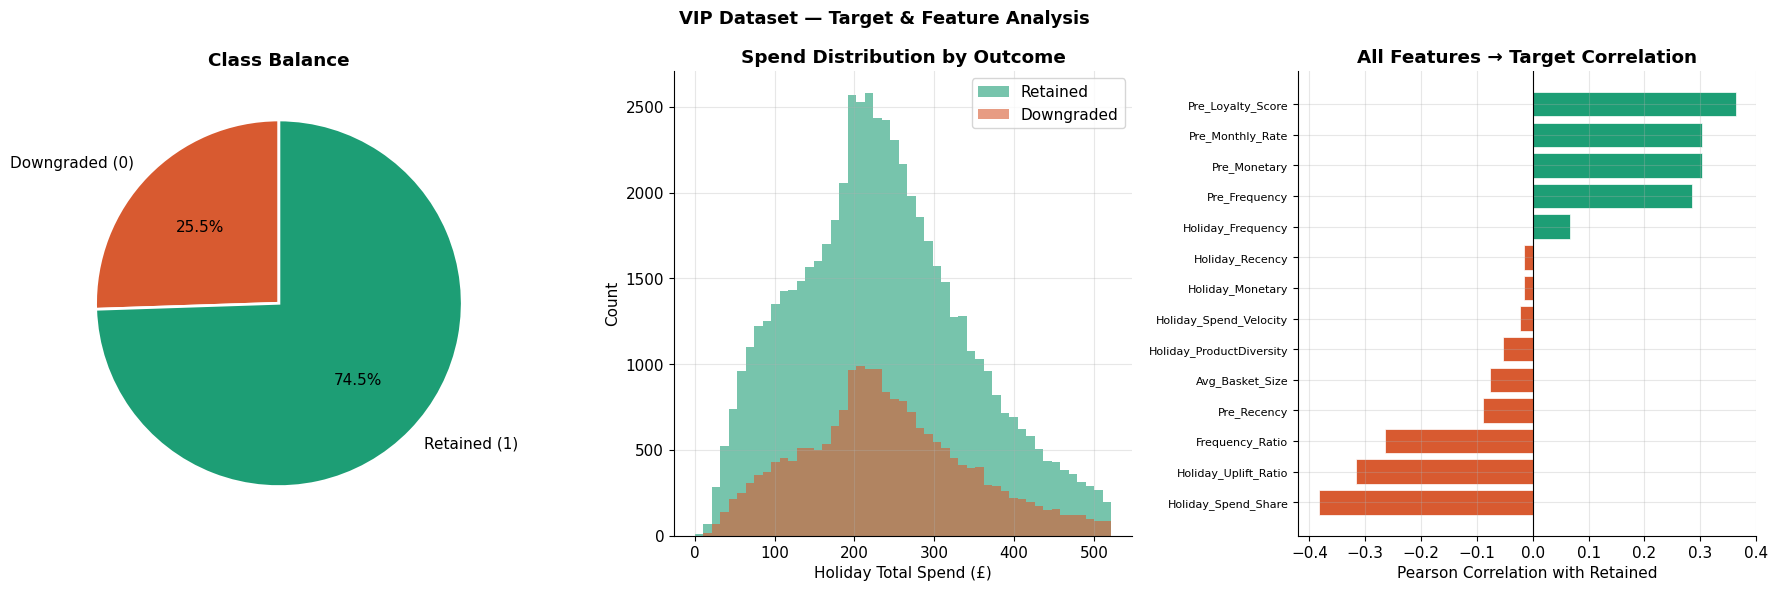

Saved: viz_03_correlations.png

KEY: Features with NEGATIVE correlation drive churn.
Look for Holiday_Spend_Share and Frequency_Ratio — high values = holiday-only shopper.


In [ ]:
# ============================================================
# CELL 9 — VISUALISATION 3: Target balance + feature correlations
# ============================================================
ALL_FEATURES = [
    'Holiday_Recency', 'Holiday_Frequency', 'Holiday_Monetary',
    'Holiday_ProductDiversity', 'Avg_Basket_Size', 'Holiday_Spend_Velocity',
    'Holiday_Uplift_Ratio', 'Holiday_Spend_Share', 'Frequency_Ratio',
    'Pre_Frequency', 'Pre_Monetary', 'Pre_Monthly_Rate',
    'Pre_Recency', 'Pre_Loyalty_Score'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('VIP Dataset — Target & Feature Analysis', fontsize=13, fontweight='bold')

# Panel 1: class balance
counts = vip_data['Retained'].value_counts().sort_index()
axes[0].pie(
    counts, labels=['Downgraded (0)', 'Retained (1)'],
    colors=['#D85A30', '#1D9E75'], autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Class Balance', fontweight='bold')

# Panel 2: spend distribution by outcome
ax = axes[1]
bins = np.linspace(0, vip_data['Holiday_Monetary'].quantile(0.97), 50)
ax.hist(vip_data[vip_data['Retained']==1]['Holiday_Monetary'],
        bins=bins, alpha=0.6, color='#1D9E75', label='Retained')
ax.hist(vip_data[vip_data['Retained']==0]['Holiday_Monetary'],
        bins=bins, alpha=0.6, color='#D85A30', label='Downgraded')
ax.set_xlabel('Holiday Total Spend (£)'); ax.set_ylabel('Count')
ax.set_title('Spend Distribution by Outcome', fontweight='bold')
ax.legend()

# Panel 3: feature correlation with target
ax = axes[2]
corr = (
    vip_data[ALL_FEATURES + ['Retained']]
    .corr()['Retained'].drop('Retained').sort_values()
)
ax.barh(corr.index, corr.values,
        color=['#D85A30' if v < 0 else '#1D9E75' for v in corr],
        edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with Retained')
ax.set_title('All Features → Target Correlation', fontweight='bold')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('viz_03_correlations.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_03_correlations.png')
print()
print('KEY: Features with NEGATIVE correlation drive churn.')
print('Look for Holiday_Spend_Share and Frequency_Ratio — high values = holiday-only shopper.')

In [ ]:
# ============================================================
# CELL 10 — TRAIN / TEST SPLIT
# ============================================================
FEATURES = [
    # --- Core RFM (holiday) ---
    'Holiday_Recency',
    'Holiday_Frequency',
    'Holiday_Monetary',
    'Holiday_ProductDiversity',
    'Avg_Basket_Size',
    'Holiday_Spend_Velocity',
    # --- Holiday behaviour signals ---
    'Holiday_Uplift_Ratio',     # holiday spike vs normal
    'Holiday_Spend_Share',      # NEW: % of annual spend in holidays
    'Frequency_Ratio',          # NEW: holiday visits vs normal monthly visits
    # --- Pre-holiday loyalty ---
    'Pre_Frequency',
    'Pre_Monetary',
    'Pre_Monthly_Rate',         # NEW: normalised by tenure
    'Pre_Recency',
    'Pre_Loyalty_Score',        # NEW: composite loyalty signal
]

X = vip_data[FEATURES]
y = vip_data['Retained']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('='*55)
print(f'Training rows  : {X_train.shape[0]:,}')
print(f'Test rows      : {X_test.shape[0]:,}')
print(f'Features       : {X_train.shape[1]}')
print(f'Train balance  : {y_train.mean()*100:.1f}% retained')
print('='*55)

Training rows  : 60,681
Test rows      : 20,227
Features       : 14
Train balance  : 74.5% retained


In [ ]:
# ============================================================
# CELL 11 — MODEL 1: LOGISTIC REGRESSION
#
# KEY FIX: ColumnTransformer with log-transform on skewed monetary
# features. LR assumes roughly linear relationships — on raw skewed
# data it cannot find a good boundary. Log-transforming Holiday_Monetary,
# Pre_Monetary, Pre_Monthly_Rate, Avg_Basket_Size removes the skew
# and lets LR use the full information content of those features.
# ============================================================
log_features = [
    'Holiday_Monetary', 'Pre_Monetary', 'Pre_Monthly_Rate',
    'Avg_Basket_Size', 'Pre_Loyalty_Score'
]
rest_features = [f for f in FEATURES if f not in log_features]

log_idx  = [FEATURES.index(f) for f in log_features]
rest_idx = [FEATURES.index(f) for f in rest_features]

# Pipeline: log1p → scale on monetary cols; just scale on the rest
lr_preprocessor = ColumnTransformer([
    ('log_scale', Pipeline([
        ('log',   FunctionTransformer(np.log1p, validate=False)),
        ('scale', StandardScaler())
    ]), log_idx),
    ('scale_only', StandardScaler(), rest_idx),
])

lr_pipeline = Pipeline([
    ('prep', lr_preprocessor),
    ('lr',   LogisticRegression(
        class_weight='balanced', random_state=42, max_iter=1000
    ))
])

lr_param_grid = {
    'lr__penalty': ['l1', 'l2'],
    'lr__C':       [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__solver':  ['liblinear'],
}

print('Running LR GridSearchCV (12 combos × 5 folds = 60 fits)...')
lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=5, scoring=churn_f1_scorer, n_jobs=-1, verbose=0
)
lr_grid.fit(X_train, y_train)

best_lr   = lr_grid.best_estimator_
y_pred_lr = best_lr.predict(X_test)

print('\n' + '='*55)
print('LOGISTIC REGRESSION RESULTS')
print('='*55)
print(f'Best params   : {lr_grid.best_params_}')
print(f'CV F1 (churn) : {lr_grid.best_score_:.4f}')
print('-'*55)
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Downgraded (0)', 'Retained (1)']
))
print('='*55)

Running LR GridSearchCV (12 combos × 5 folds = 60 fits)...

LOGISTIC REGRESSION RESULTS
Best params   : {'lr__C': 0.01, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
CV F1 (churn) : 0.6228
-------------------------------------------------------
                precision    recall  f1-score   support

Downgraded (0)       0.55      0.74      0.63      5162
  Retained (1)       0.90      0.80      0.84     15065

      accuracy                           0.78     20227
     macro avg       0.73      0.77      0.74     20227
  weighted avg       0.81      0.78      0.79     20227



In [ ]:
# ============================================================
# CELL 12 — MODEL 2: XGBOOST  (bug fixed + wider search)
#
# BUG FIXED: scale_pos_weight=0.34 was WRONG.
#
# Root cause: The code computed n_neg/n_pos = 15487/45194 = 0.34
# But scale_pos_weight boosts CLASS 1 (retained). Our churners are
# CLASS 0 — so setting scale_pos_weight<1 was REDUCING the model's
# attention on retained AND making it even WORSE at finding churners.
#
# CORRECT FIX: use compute_sample_weight which directly assigns
# higher weights to whichever class has fewer samples, regardless
# of which class label it is. This works for both class 0 and class 1.
# ============================================================
print('Computing correct sample weights (class 0 = churners gets higher weight)...')
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Verify the fix: churner weights should be ~3x retained weights
churn_w    = sample_weights[y_train == 0].mean()
retained_w = sample_weights[y_train == 1].mean()
print(f'   Avg weight for churners  (0): {churn_w:.3f}')
print(f'   Avg weight for retained  (1): {retained_w:.3f}')
print(f'   Churn/Retained ratio        : {churn_w/retained_w:.2f}x  (should be ~3x)')

xgb_param_dist = {
    'n_estimators'    : [100, 200, 300, 400, 500],
    'max_depth'       : [3, 4, 5, 6],
    'learning_rate'   : [0.01, 0.03, 0.05, 0.1, 0.15],
    'subsample'       : [0.6, 0.7, 0.8, 0.9],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5, 10],
    'gamma'           : [0, 0.1, 0.2, 0.3, 0.5],
    'reg_alpha'       : [0, 0.1, 0.5, 1.0],   # NEW: L1 regularisation
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0], # NEW: L2 regularisation
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1,
    verbosity=0
    # NOTE: NO scale_pos_weight — we handle imbalance via sample_weight in .fit()
)

print('Running XGB RandomizedSearchCV (40 combos × 3 folds = 120 fits)...')
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=3,
    scoring=churn_f1_scorer,
    random_state=42,
    n_jobs=1,
    verbose=1
)
# Pass sample weights into every CV fold via fit_params
xgb_search.fit(X_train, y_train, sample_weight=sample_weights)

best_xgb   = xgb_search.best_estimator_
# Re-fit best params with sample_weight on full train set
best_xgb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_xgb = best_xgb.predict(X_test)

print('\n' + '='*55)
print('XGBOOST RESULTS')
print('='*55)
print(f'Best params   : {xgb_search.best_params_}')
print(f'CV F1 (churn) : {xgb_search.best_score_:.4f}')
print('-'*55)
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Downgraded (0)', 'Retained (1)']
))
print('='*55)

Computing correct sample weights (class 0 = churners gets higher weight)...
   Avg weight for churners  (0): 1.959
   Avg weight for retained  (1): 0.671
   Churn/Retained ratio        : 2.92x  (should be ~3x)
Running XGB RandomizedSearchCV (40 combos × 3 folds = 120 fits)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits


ValueError: 
All the 120 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
120 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Aryan Yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Aryan Yadav\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
TypeError: XGBClassifier.fit() got an unexpected keyword argument 'xgbclassifier__sample_weight'



LR threshold table:
 Threshold  F1_churn  Recall  Precision
      0.25    0.5075  0.4016     0.6892
      0.30    0.5517  0.4707     0.6663
      0.35    0.5844  0.5351     0.6438
      0.40    0.6118  0.6025     0.6215
      0.45    0.6318  0.6769     0.5923
      0.50    0.6323  0.7356     0.5544
      0.55    0.6254  0.7950     0.5154
      0.60    0.6074  0.8487     0.4729
      0.65    0.5788  0.8915     0.4285
      0.70    0.5454  0.9301     0.3858
      0.75    0.5094  0.9551     0.3473
      0.80    0.4759  0.9744     0.3148
  -> Best threshold: 0.5  |  Best F1: 0.6323

XGB threshold table:
 Threshold  F1_churn  Recall  Precision
      0.25    0.5760  0.5118     0.6585
      0.30    0.6130  0.5969     0.6301
      0.35    0.6286  0.6556     0.6039
      0.40    0.6361  0.7083     0.5773
      0.45    0.6375  0.7536     0.5525
      0.50    0.6320  0.7923     0.5256
      0.55    0.6227  0.8222     0.5011
      0.60    0.6122  0.8543     0.4771
      0.65    0.5957  0.8818    

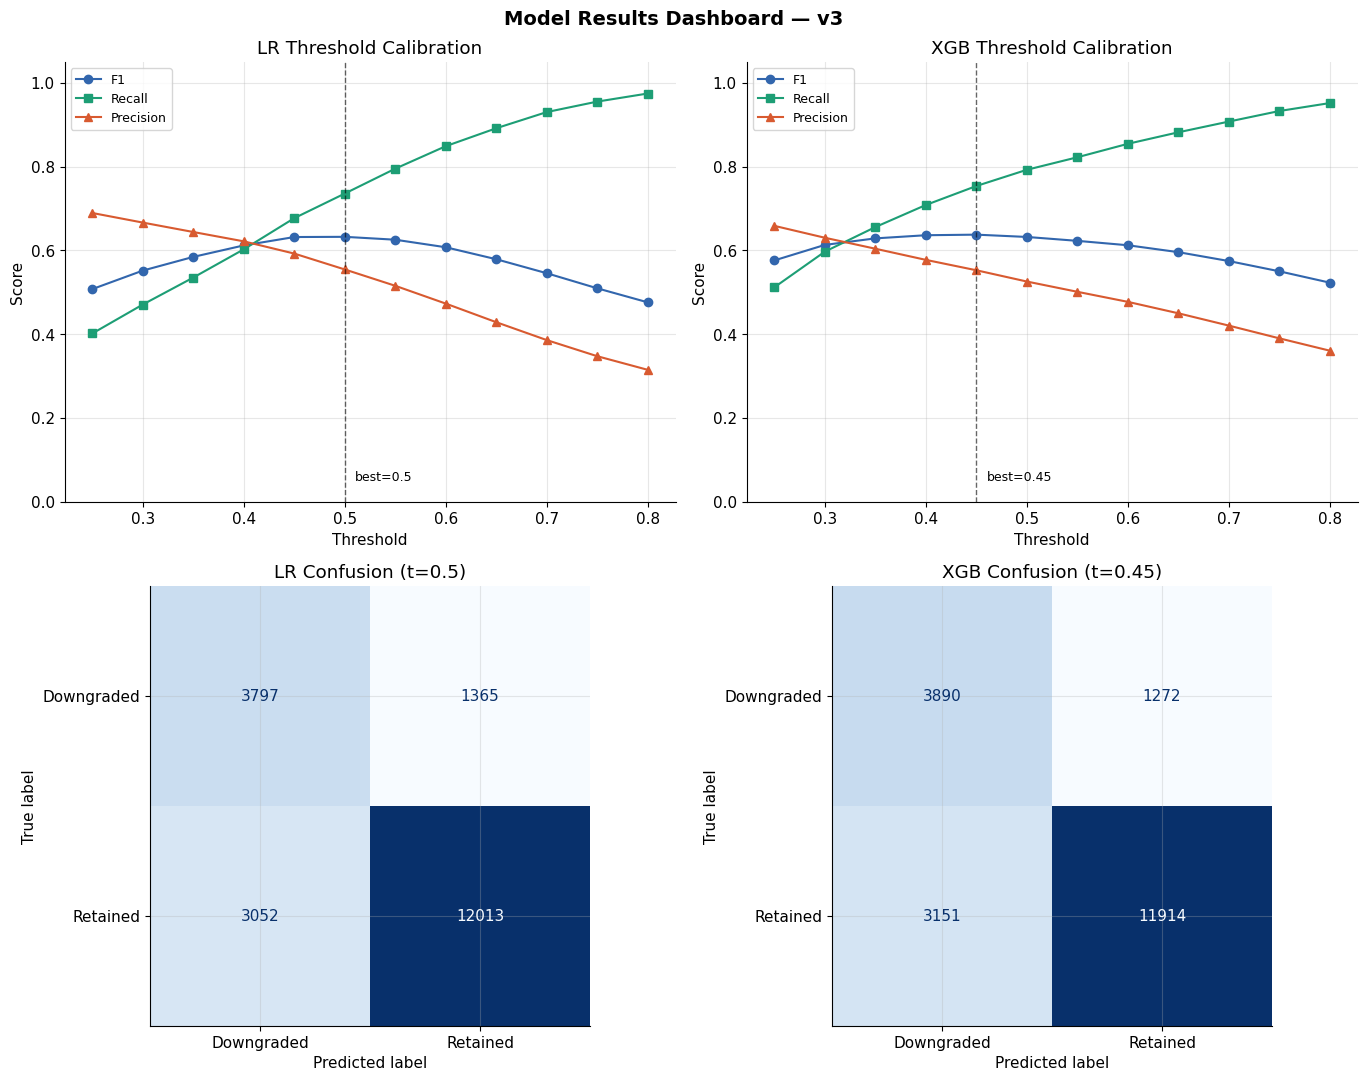

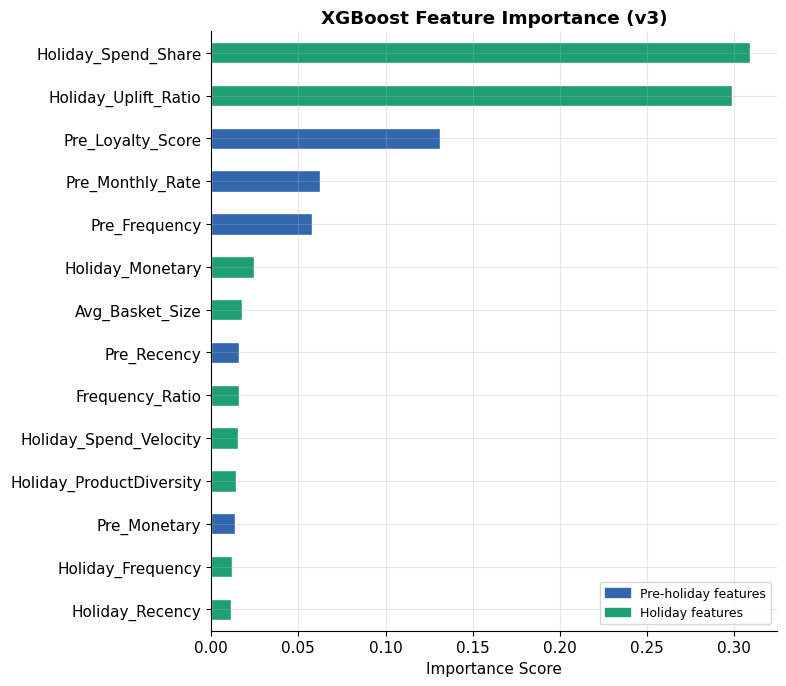

Saved: viz_04_results_dashboard.png, viz_05_feature_importance.png


In [ ]:
# ============================================================
# CELL 13 — VISUALISATION 4 + THRESHOLD CALIBRATION
# ============================================================
def calibrate_threshold(model, X, y_true, label):
    probs = model.predict_proba(X)[:, 1]
    rows  = []
    for t in np.arange(0.25, 0.82, 0.05):
        preds = (probs >= t).astype(int)
        rows.append({
            'Threshold': round(t, 2),
            'F1_churn' : round(f1_score(y_true, preds, pos_label=0, zero_division=0), 4),
            'Recall'   : round(recall_score(y_true, preds, pos_label=0, zero_division=0), 4),
            'Precision': round(precision_score(y_true, preds, pos_label=0, zero_division=0), 4),
        })
    df     = pd.DataFrame(rows)
    best_t = df.loc[df['F1_churn'].idxmax(), 'Threshold']
    print(f'\n{label} threshold table:')
    print(df.to_string(index=False))
    print(f'  -> Best threshold: {best_t}  |  Best F1: {df["F1_churn"].max():.4f}')
    return df, best_t, probs

lr_tdf,  lr_t,  lr_probs  = calibrate_threshold(best_lr,  X_test, y_test, 'LR')
xgb_tdf, xgb_t, xgb_probs = calibrate_threshold(best_xgb, X_test, y_test, 'XGB')

y_lr_opt  = (lr_probs  >= lr_t ).astype(int)
y_xgb_opt = (xgb_probs >= xgb_t).astype(int)

# --- 4-panel results dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Model Results Dashboard — v3', fontsize=14, fontweight='bold')

for ax, df, t, title in [
    (axes[0,0], lr_tdf,  lr_t,  'LR Threshold Calibration'),
    (axes[0,1], xgb_tdf, xgb_t, 'XGB Threshold Calibration'),
]:
    ax.plot(df['Threshold'], df['F1_churn'],  marker='o', label='F1',        color='#3266ad')
    ax.plot(df['Threshold'], df['Recall'],    marker='s', label='Recall',    color='#1D9E75')
    ax.plot(df['Threshold'], df['Precision'], marker='^', label='Precision', color='#D85A30')
    ax.axvline(t, color='black', linestyle='--', linewidth=1, alpha=0.6)
    ax.text(t+0.01, 0.05, f'best={t}', fontsize=9)
    ax.set_title(title); ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

# Confusion matrices at optimal threshold
for ax, y_pred, title in [
    (axes[1,0], y_lr_opt,  f'LR Confusion (t={lr_t})'),
    (axes[1,1], y_xgb_opt, f'XGB Confusion (t={xgb_t})'),
]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['Downgraded', 'Retained'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(title)

plt.tight_layout()
plt.savefig('viz_04_results_dashboard.png', bbox_inches='tight', dpi=100)
plt.show()

# XGB Feature importance
fig2, ax2 = plt.subplots(figsize=(8, 7))
imp = pd.Series(best_xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
colors_fi = ['#3266ad' if 'Pre_' in f else '#1D9E75' for f in imp.index]
imp.plot(kind='barh', ax=ax2, color=colors_fi, edgecolor='white')
ax2.set_title('XGBoost Feature Importance (v3)', fontweight='bold')
ax2.set_xlabel('Importance Score')
from matplotlib.patches import Patch
ax2.legend(handles=[
    Patch(color='#3266ad', label='Pre-holiday features'),
    Patch(color='#1D9E75', label='Holiday features'),
], fontsize=9)
plt.tight_layout()
plt.savefig('viz_05_feature_importance.png', bbox_inches='tight', dpi=100)
plt.show()
print('Saved: viz_04_results_dashboard.png, viz_05_feature_importance.png')

In [ ]:
# ============================================================
# CELL 14 — FINAL MODEL SELECTION + EXPORT
# ============================================================
lr_f1   = f1_score(y_test, y_lr_opt,  pos_label=0)
xgb_f1  = f1_score(y_test, y_xgb_opt, pos_label=0)
lr_rec  = recall_score(y_test, y_lr_opt,  pos_label=0)
xgb_rec = recall_score(y_test, y_xgb_opt, pos_label=0)
lr_acc  = float((y_lr_opt  == y_test.values).mean())
xgb_acc = float((y_xgb_opt == y_test.values).mean())

print('=' * 62)
print('FINAL COMPARISON  (Class 0 = Churner metrics)')
print('=' * 62)
print(f'{"Model":<25} {"Churn F1":>9} {"Recall":>8} {"Accuracy":>10} {"Threshold":>11}')
print('-' * 62)
print(f'{"Logistic Regression":<25} {lr_f1:>9.4f} {lr_rec:>8.4f} {lr_acc:>10.4f} {lr_t:>11.2f}')
print(f'{"XGBoost (fixed)":<25} {xgb_f1:>9.4f} {xgb_rec:>8.4f} {xgb_acc:>10.4f} {xgb_t:>11.2f}')
print('=' * 62)

# Auto-select winner
if xgb_f1 >= lr_f1:
    winner, w_name, w_t, w_probs = best_xgb, 'XGBoost', xgb_t, xgb_probs
else:
    winner, w_name, w_t, w_probs = best_lr, 'Logistic Regression', lr_t, lr_probs

print(f'WINNER: {w_name}')
print('FINAL CLASSIFICATION REPORT:')
w_preds = (w_probs >= w_t).astype(int)
print(classification_report(
    y_test, w_preds,
    target_names=['Downgraded (0)', 'Retained (1)']
))

# ── Save model ────────────────────────────────────────────────────────────────
joblib.dump(winner, 'vip_churn_v3_model.pkl')
print('Saved: vip_churn_v3_model.pkl')

# ── Generate at-risk hit list ─────────────────────────────────────────────────
# Remove Churn_Risk_Probability if it already exists from a re-run
if 'Churn_Risk_Probability' in vip_data.columns:
    vip_data.drop(columns=['Churn_Risk_Probability'], inplace=True)

_vip_features = vip_data[FEATURES]
all_probs = winner.predict_proba(_vip_features)[:, 1]
vip_data['Churn_Risk_Probability'] = 1 - all_probs   # P(churn) = 1 - P(retained)

export_cols = [
    'Churn_Risk_Probability', 'Holiday_Monetary', 'Pre_Monetary',
    'Holiday_Frequency', 'Holiday_Uplift_Ratio', 'Holiday_Spend_Share'
]
at_risk = (
    vip_data[vip_data['Churn_Risk_Probability'] >= 0.50][export_cols]
    .sort_values(by=['Churn_Risk_Probability', 'Holiday_Monetary'],
                 ascending=[False, False])
)
at_risk.to_csv('At_Risk_VIPs_v3.csv')
print(f'Saved: At_Risk_VIPs_v3.csv  ({len(at_risk):,} VIPs flagged)')
print(f'Avg holiday spend of flagged VIPs: £{at_risk["Holiday_Monetary"].mean():,.2f}')
display(at_risk.head(10))
